In [1]:
# ---- Cell 1: Imports ----
import sys, math, warnings, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

warnings.filterwarnings("ignore")

# Resolve project root so the project modules import cleanly
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Project imports
from config.settings    import solver_variable_names, solver_flux_names
from config.initialize  import parameters, operating_inputs, init_x_for
from model.dualscale    import PEMFC
from model.kinetic_eq   import Rproton, eta_ccl
from model.coefficients import n_cell

# Sweep grid used to pick experimental points to compare against
I_tested   = [10, 20, 30, 35, 40]      # A      current points
TFC_tested = [50, 60, 70]              # degC   cell temperature
PAC_tested = [1.3e5, 1.4e5, 1.5e5]     # Pa     anode/cathode pressure
RHC_tested = [0, 50]                   # %      cathode relative humidity

print("Imports OK.")


Imports OK.


In [2]:
# ---- Cell 2: Import experiment data ----
exp_file       = project_root / "data" / "Polar_curves.xlsx"
polardata_exp  = pd.read_excel(exp_file, sheet_name=None)

print(f"Loaded {len(polardata_exp)} conditions from {exp_file.name}")
for name, df in polardata_exp.items():
    i_min, i_max = df["I_LOAD"].min(), df["I_LOAD"].max()
    print(f"  {name:18s}  {len(df):3d} points,  I = {i_min:.1f}-{i_max:.1f} A")


Loaded 12 conditions from Polar_curves.xlsx
  T50_P300_HRC0         7 points,  I = 9.9-49.9 A
  T50_P300_HRC50        7 points,  I = 10.0-50.1 A
  T50_P400_HRC50        7 points,  I = 10.0-50.1 A
  T50_P500_HRC50        7 points,  I = 10.0-50.1 A
  T60_P300_HRC0         7 points,  I = 10.2-50.1 A
  T60_P300_HRC50        7 points,  I = 9.9-50.1 A
  T60_P400_HRC50        7 points,  I = 9.9-50.1 A
  T60_P500_HRC50        7 points,  I = 9.9-50.1 A
  T70_P300_HRC0         7 points,  I = 10.0-50.0 A
  T70_P300_HRC50        7 points,  I = 10.0-50.0 A
  T70_P400_HRC50        7 points,  I = 10.0-50.0 A
  T70_P500_HRC50        7 points,  I = 10.0-50.0 A


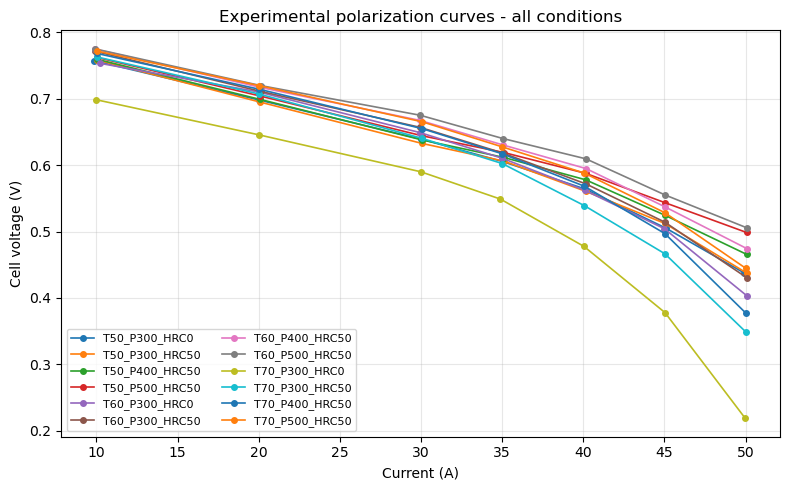

In [3]:
# ---- Cell 3: Plot the experimental data ----
fig, ax = plt.subplots(figsize=(8, 5))
for name, df in polardata_exp.items():
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
    ax.plot(i_exp, v_exp, "o-", linewidth=1.2, markersize=4, label=name)

ax.set_xlabel("Current (A)")
ax.set_ylabel("Cell voltage (V)")
ax.set_title("Experimental polarization curves - all conditions")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="best", ncol=2)
plt.tight_layout()
plt.show()


In [4]:
# ---- Cell 4: Setup the undetermined parameters ----
# Edit values in `manual_params` to fit the curves by hand, then re-run
# cells 5 / 6 to see the new fit.
manual_params = {
    "OCV":          0.93,    # V        open-circuit voltage
    "i0_c_ref":     0.16,    # A/m^2    cathode exchange current density (ref)
    "kappa_c":      12,     # -        O2 reaction order
    "tau":          1.01,    # -        GDL tortuosity exponent
    "Re":           2.2e-7,  # Ohm.m^2  electronic resistance
    "epsilon_mc":   0.399,   # -        ionomer fraction in micro CL
    "epsilon_gdl":  0.5,     # -        GDL porosity
    "epsilon_c":    0.189,   # -        cathode ionomer fraction
    "epsilon_cl":   0.3,    # -        catalyst-layer porosity
    "a_slim":       0.01,     # -        saturation-switch slope
    "b_slim":       0.1,     # -        saturation-switch intercept
    "a_switch":     0.1,     # -        saturation-switch threshold
    "Hcl":          1.5e-5,    # m        catalyst-layer thickness
    "Hgdl":         3.0e-4,    # m        GDL thickness
}


def simulate_polar(cond_key, params_override, verbose=True):
    """Run the dual-scale model (without BoP) at every I in I_tested for
    one experimental condition. Robust to per-point failures: any current
    that the solver cannot handle is skipped (with a printed note), and
    only the successful (i, Ucell) pairs are returned.

    Speed: ~0.5-1.5 s per current point on a typical laptop thanks to a
    reduced n_group_pt and a shorter t_span -- still long enough for the
    steady-state polarization voltage to settle.

    cond_key format e.g. "T60_P400_HRC50":
        T   in degC,
        P   encoded so that  Pa_des = int(part) * 100 + 1000   [Pa],
        RHC in %.
    """
    # Parse condition key
    T_des = int(cond_key.split("_")[0][1:])
    P_des = int(cond_key.split("_")[1][1:]) * 1e2 + 1e3
    RHC   = int(cond_key.split("_")[2][3:])

    # Local copies so we never mutate the global defaults
    p  = deepcopy(parameters);  p.update(params_override)
    p["aux_system"]  = False        # calibration uses dual-scale w/o BoP
    # Note: do NOT override p["n_group_pt"] here -- init_x() reads it from
    # config.initialize.computing_parameters (module-level), so changing the
    # per-trial dict would desync the model state size from init_x output.
    op = deepcopy(operating_inputs)
    op["Tfc"]       = T_des + 273.15
    op["Pa_des"]    = P_des
    op["Pc_des"]    = P_des
    op["Phi_c_des"] = RHC / 100

    model = PEMFC(param=p, operating_inputs=op,
                  variable_names=solver_variable_names,
                  flux_names=solver_flux_names)

    i_keep, Ucell_keep = [], []
    t_per_point = []
    for I_LOAD in I_tested:
        i_density = I_LOAD / p["Aact"]
        op["current_density"] = lambda t, _i=i_density: _i
        t0 = time.perf_counter()
        try:
            x0  = init_x_for("dual-scale", op, model.parameters)
            sol = solve_ivp(model.dxdt, (0, 30), x0,
                            method="BDF", max_step=2e-1)
            if not sol.success:
                if verbose:
                    print(f"    I = {I_LOAD:5.1f} A  ->  solver failed: {sol.message}")
                continue
            last = {k: sol.y[idx, -1] for idx, k in enumerate(model.variable_names)}
            Rmem, _, _ = Rproton(last, model.parameters, op)
            eta_c      = eta_ccl(last, op, model.parameters)
            Ucell      = p["OCV"] - i_density * (sum(Rmem) + p["Re"]) - eta_c
            if not (np.isfinite(Ucell) and 0.0 < Ucell < 1.3):
                if verbose:
                    print(f"    I = {I_LOAD:5.1f} A  ->  unphysical Ucell = {Ucell}")
                continue
            i_keep.append(I_LOAD)
            Ucell_keep.append(float(Ucell))
            t_per_point.append(time.perf_counter() - t0)
        except Exception as exc:
            if verbose:
                print(f"    I = {I_LOAD:5.1f} A  ->  exception: {type(exc).__name__}: {exc}")
            continue
    if verbose:
        avg = (sum(t_per_point) / len(t_per_point)) if t_per_point else 0.0
        print(f"  {cond_key}: {len(i_keep)}/{len(I_tested)} points OK   (avg {avg:.2f} s/point)")
    return i_keep, Ucell_keep


print("Manual params dict ready.")
print("Tip: tweak values above, then re-run cells 5/6 -- you don't need to re-run cells 1-3.")


Manual params dict ready.
Tip: tweak values above, then re-run cells 5/6 -- you don't need to re-run cells 1-3.


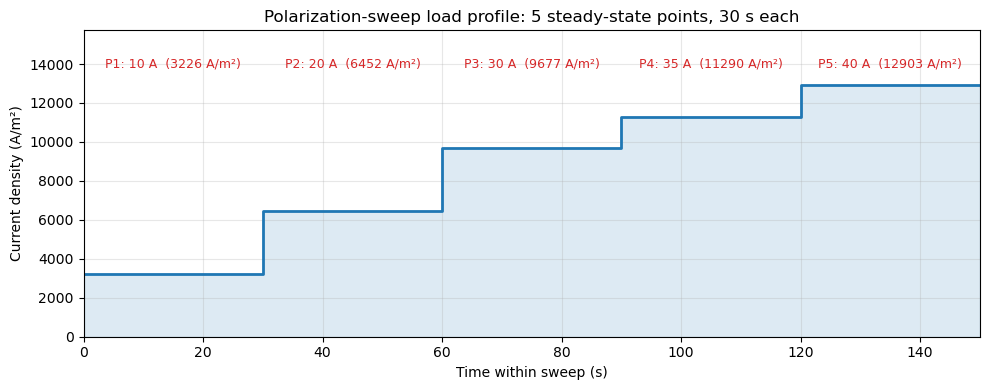

For each polar point we hold a constant load for 30 s:
  P1:  I =  10.0 A  ->  i =  3225.8 A/m²
  P2:  I =  20.0 A  ->  i =  6451.6 A/m²
  P3:  I =  30.0 A  ->  i =  9677.4 A/m²
  P4:  I =  35.0 A  ->  i = 11290.3 A/m²
  P5:  I =  40.0 A  ->  i = 12903.2 A/m²


In [5]:
# ---- Cell 5: Load profile used to generate each polarization point ----
# Polarization sweep methodology: for every current in I_tested we hold a
# constant load for t_hold seconds and read off the steady-state cell
# voltage. The plot below visualises that load profile as a staircase
# along a single time axis -- each step corresponds to one polar point.
#
# Note: inside simulate_polar() each step is actually an INDEPENDENT
# simulation that restarts from the same initial state. The staircase
# layout below is purely for visualisation.

t_hold = 30.0       # seconds per point -- must match the t_span used inside simulate_polar()
i_A_per_m2 = [I / parameters["Aact"] for I in I_tested]

# Build the staircase
t_stairs, i_stairs = [], []
t0 = 0.0
for i_density in i_A_per_m2:
    t_stairs += [t0, t0 + t_hold]
    i_stairs += [i_density, i_density]
    t0 += t_hold

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(t_stairs, i_stairs, where="post", linewidth=2, color="tab:blue")
ax.fill_between(t_stairs, 0, i_stairs, step="post", alpha=0.15, color="tab:blue")

# Annotate each step with its I_tested value (single-line label)
y_top = max(i_stairs) * 1.06
for k, (I, i_d) in enumerate(zip(I_tested, i_A_per_m2)):
    t_mid = (k + 0.5) * t_hold
    label = "P" + str(k + 1) + ": " + str(I) + " A  (" + format(i_d, ".0f") + " A/m²)"
    ax.text(t_mid, y_top, label, ha="center", va="bottom", fontsize=9,
            color="tab:red", rotation=0)

ax.set_xlim(0, len(I_tested) * t_hold)
ax.set_ylim(0, y_top * 1.15)
ax.set_xlabel("Time within sweep (s)")
ax.set_ylabel("Current density (A/m²)")
ax.set_title("Polarization-sweep load profile: "
             + str(len(I_tested)) + " steady-state points, "
             + format(t_hold, "g") + " s each")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("For each polar point we hold a constant load for", format(t_hold, "g"), "s:")
for k, (I, i_d) in enumerate(zip(I_tested, i_A_per_m2), 1):
    print("  P" + str(k) + ":  I = " + format(I, "5.1f") + " A  ->  i = "
          + format(i_d, "7.1f") + " A/m²")


Simulating T60_P400_HRC50 ...
  T60_P400_HRC50: 5/5 points OK   (avg 1.77 s/point)


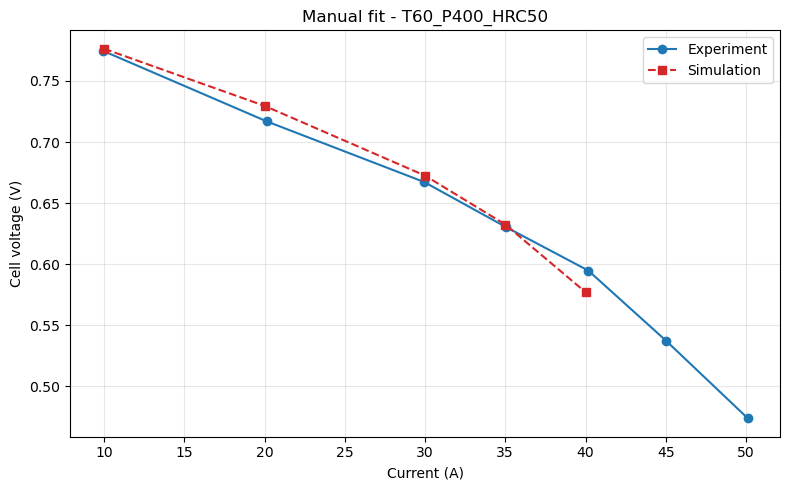

RMSE on 5 points: 10.1 mV


In [6]:
# ---- Cell 6: Plot one-condition fit ----
# Change CHOSEN_COND to any key printed by cell 2.
CHOSEN_COND = "T60_P400_HRC50"
print(f"Simulating {CHOSEN_COND} ...")

# Experimental
df    = polardata_exp[CHOSEN_COND]
i_exp = df["I_LOAD"].to_numpy(dtype=float)
v_exp = df["VFC"].to_numpy(dtype=float) / n_cell

# Simulation with current manual_params
i_sim, v_sim = simulate_polar(CHOSEN_COND, manual_params)

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(i_exp, v_exp, "o-",  color="tab:blue", markersize=6, label="Experiment")
if i_sim:
    ax.plot(i_sim, v_sim, "s--", color="tab:red",  markersize=6, label="Simulation")
ax.set_xlabel("Current (A)")
ax.set_ylabel("Cell voltage (V)")
ax.set_title(f"Manual fit - {CHOSEN_COND}")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# RMSE on the simulation points only (skip any that failed)
if i_sim:
    idx_match = [int(np.argmin((i_t - i_exp) ** 2)) for i_t in i_sim]
    rmse = float(np.sqrt(np.mean((np.array(v_sim) - v_exp[idx_match]) ** 2)))
    print(f"RMSE on {len(i_sim)} points: {rmse * 1000:.1f} mV")
else:
    print("No simulation points succeeded -- check the parameters in cell 4.")


Simulating T60_P400_HRC50 ...
  T60_P400_HRC50: 5/5 points OK   (avg 1.79 s/point)
Simulating T60_P500_HRC50 ...
  T60_P500_HRC50: 5/5 points OK   (avg 1.96 s/point)


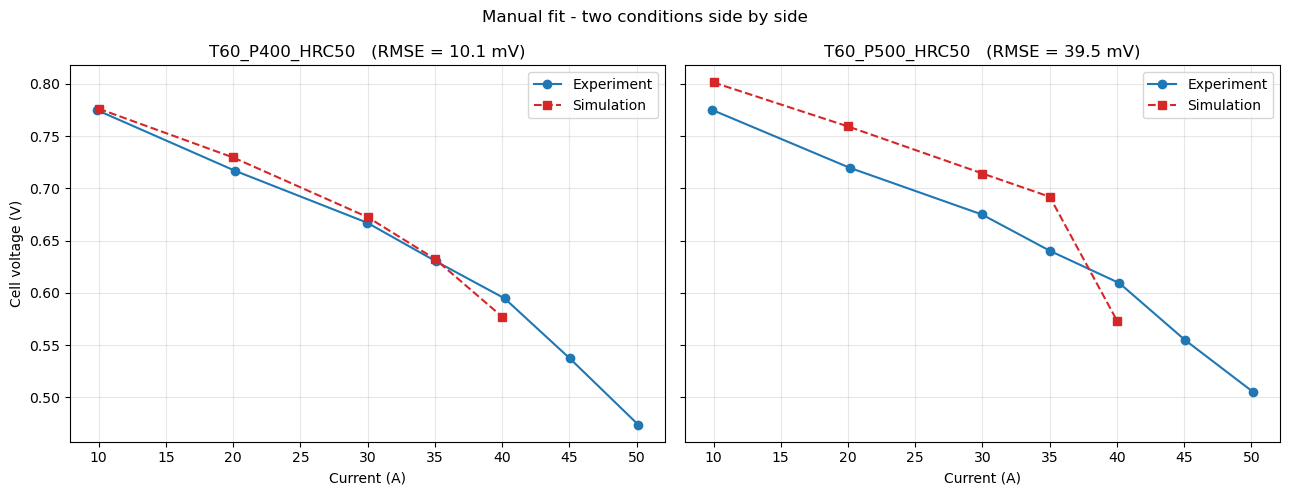

In [7]:
# ---- Cell 7: Plot two-condition fit ----
# Change CHOSEN_2 to any two keys printed by cell 2.
CHOSEN_2 = ["T60_P400_HRC50", "T60_P500_HRC50"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, cond_key in zip(axes, CHOSEN_2):
    print(f"Simulating {cond_key} ...")
    df    = polardata_exp[cond_key]
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell

    i_sim, v_sim = simulate_polar(cond_key, manual_params)

    ax.plot(i_exp, v_exp, "o-",  color="tab:blue", markersize=6, label="Experiment")
    if i_sim:
        ax.plot(i_sim, v_sim, "s--", color="tab:red",  markersize=6, label="Simulation")

        idx_match = [int(np.argmin((i_t - i_exp) ** 2)) for i_t in i_sim]
        rmse = float(np.sqrt(np.mean((np.array(v_sim) - v_exp[idx_match]) ** 2)))
        ax.set_title(f"{cond_key}   (RMSE = {rmse*1000:.1f} mV)")
    else:
        ax.set_title(f"{cond_key}   (no sim points)")

    ax.set_xlabel("Current (A)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

axes[0].set_ylabel("Cell voltage (V)")
plt.suptitle("Manual fit - two conditions side by side", fontsize=12)
plt.tight_layout()
plt.show()
